# Titanic — 81% Optimized Version (Redesigned for Learning)

This notebook rebuilds the uploaded **0.8134 Titanic solution** using:

- modern Python 3 / pandas syntax
- the `X`, `y`, `X_test` naming style
- short, readable steps instead of many helper functions
- the same main ideas: EDA → feature engineering → feature selection → model comparison → Random Forest tuning → Kaggle submission
- small **"syntax pattern to remember"** notes so the code is easier to learn

> The original notebook reported a public leaderboard score of **0.8134**.  
> This version preserves its overall strategy, but modern library versions and small compatibility fixes can make the exact Kaggle score differ slightly.

## 1. Imports

We only import what we actually use.

In [35]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
from zipfile import ZipFile
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold

pd.set_option("display.max_columns", 100)

## 2. Load the Titanic data

If you are using Kaggle's Titanic competition notebook, these paths should work directly.

In [36]:
ZIP_PATH = Path(r"C:\Users\whelm\OneDrive\Desktop\titanic.zip")
DATA_DIR = Path(r"C:\Users\whelm\OneDrive\Desktop\titanic_data")
DATA_DIR.mkdir(exist_ok=True)

if not (DATA_DIR / "train.csv").exists() or not (DATA_DIR / "test.csv").exists():
    with ZipFile(ZIP_PATH) as archive:
        archive.extractall(DATA_DIR)

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print("Train shape:", train.shape)
print("Test shape :", test.shape)

train.head()

Train shape: (891, 12)
Test shape : (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### What are `X` and `y`?

Our usual machine-learning structure is:

```python
X = input features
y = answer we want to predict
```

For Titanic:

```text
X → Age, Sex, Fare, Pclass, Name, ...
y → Survived
```

In [37]:
X = train.drop(columns=["Survived"])
y = train["Survived"]

X.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Syntax pattern to remember

```python
df.drop(columns=["column"])
```

means **take the dataframe and remove that column**.

```python
df["column"]
```

means **take only that column**.

# Part I — Exploratory Data Analysis (EDA)

EDA is where we look at the data and ask:

> Which features seem related to survival?

We use a copy so our plots do not accidentally change the original training data.

In [38]:
eda = train.copy()

# Fill Age only for visualization
eda["Age"] = eda["Age"].fillna(eda["Age"].median())

# 1 = died, 0 = survived
eda["Died"] = 1 - eda["Survived"]

## 3. Survival by Sex

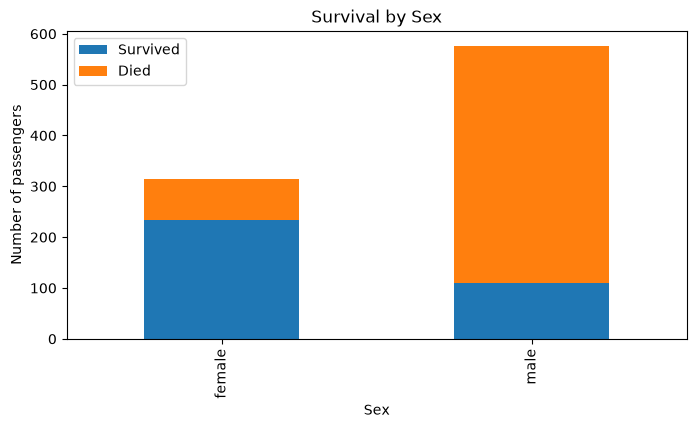

In [39]:
sex_counts = eda.groupby("Sex")[["Survived", "Died"]].sum()

sex_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 4)
)

plt.ylabel("Number of passengers")
plt.title("Survival by Sex")
plt.show()

### Pattern to remember

```python
df.groupby("group_column")[["value1", "value2"]].sum()
```

Read it left → right:

**group by something → keep the columns you care about → add their values**

## 4. Survival ratio by Sex

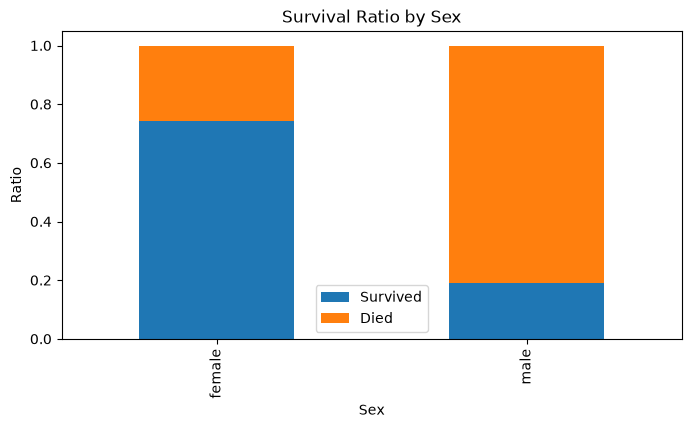

In [40]:
sex_ratio = eda.groupby("Sex")[["Survived", "Died"]].mean()

sex_ratio.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 4)
)

plt.ylabel("Ratio")
plt.title("Survival Ratio by Sex")
plt.show()

Because `Survived` contains only `0` and `1`, its mean is also the **survival rate**.

Example:

```text
0, 1, 1, 0, 1

mean = 3 / 5 = 0.60
```

So `0.60` means a 60% survival rate.

## 5. Age + Sex + Survival

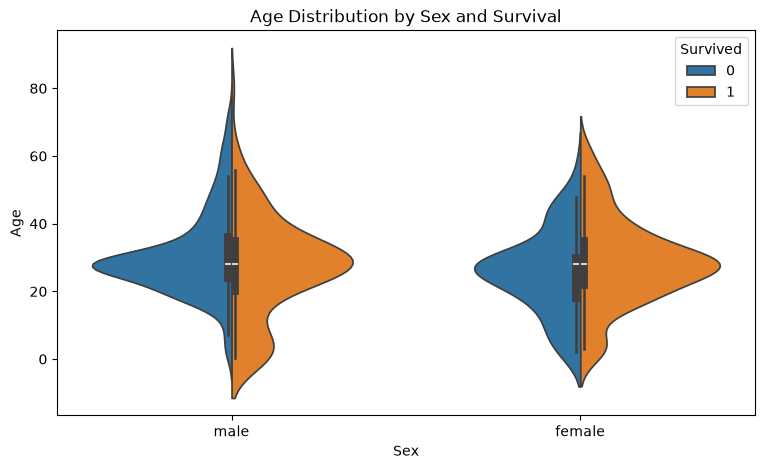

In [41]:
plt.figure(figsize=(9, 5))

sns.violinplot(
    data=eda,
    x="Sex",
    y="Age",
    hue="Survived",
    split=True
)

plt.title("Age Distribution by Sex and Survival")
plt.show()

Remember how to read a violin plot:

```text
X-axis → category
Y-axis → value
width  → how many observations are around that value
hue    → another group, here Survived
```

## 6. Fare + Survival

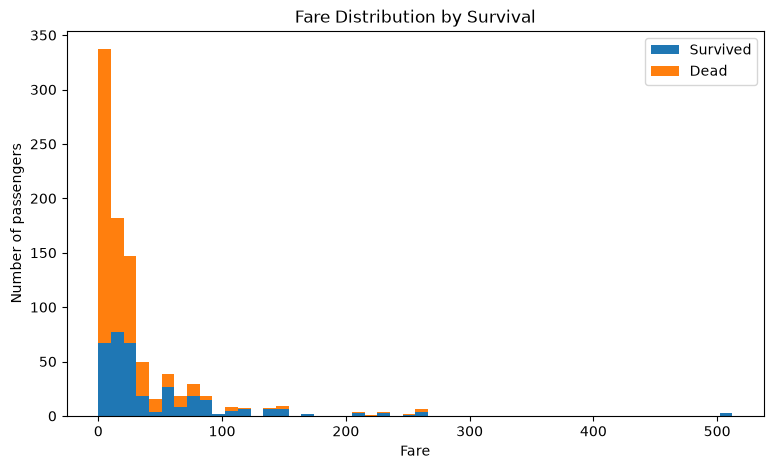

In [42]:
survived_fare = eda[eda["Survived"] == 1]["Fare"]
dead_fare = eda[eda["Survived"] == 0]["Fare"]

plt.figure(figsize=(9, 5))

plt.hist(
    [survived_fare, dead_fare],
    bins=50,
    stacked=True,
    label=["Survived", "Dead"]
)

plt.xlabel("Fare")
plt.ylabel("Number of passengers")
plt.legend()
plt.title("Fare Distribution by Survival")
plt.show()

### Filtering pattern to remember

```python
df[df["column"] == value]["other_column"]
```

Example:

```python
eda[eda["Survived"] == 1]["Fare"]
```

means:

**take `eda` → keep survivors only → take their Fare values**

## 7. Age + Fare + Survival

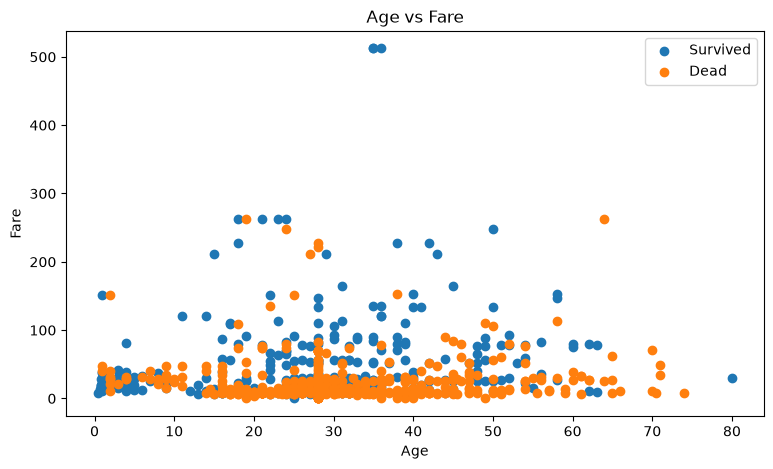

In [43]:
survived = eda[eda["Survived"] == 1]
dead = eda[eda["Survived"] == 0]

plt.figure(figsize=(9, 5))

plt.scatter(
    survived["Age"],
    survived["Fare"],
    label="Survived"
)

plt.scatter(
    dead["Age"],
    dead["Fare"],
    label="Dead"
)

plt.xlabel("Age")
plt.ylabel("Fare")
plt.legend()
plt.title("Age vs Fare")
plt.show()

Scatter plot structure:

```python
plt.scatter(x_values, y_values)
```

So here:

```text
X-axis → Age
Y-axis → Fare
```

## 8. Passenger Class + Fare

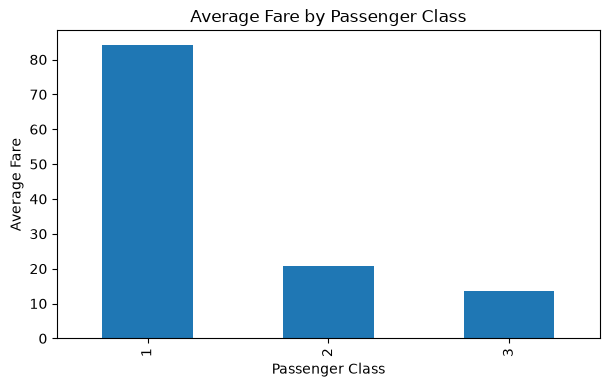

In [44]:
average_fare = eda.groupby("Pclass")["Fare"].mean()

average_fare.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.xlabel("Passenger Class")
plt.ylabel("Average Fare")
plt.title("Average Fare by Passenger Class")
plt.show()

This asks:

> What was the average ticket price inside each passenger class?

General pattern:

```python
df.groupby("group_column")["value_column"].mean()
```

## 9. Embarkation Port + Fare + Survival

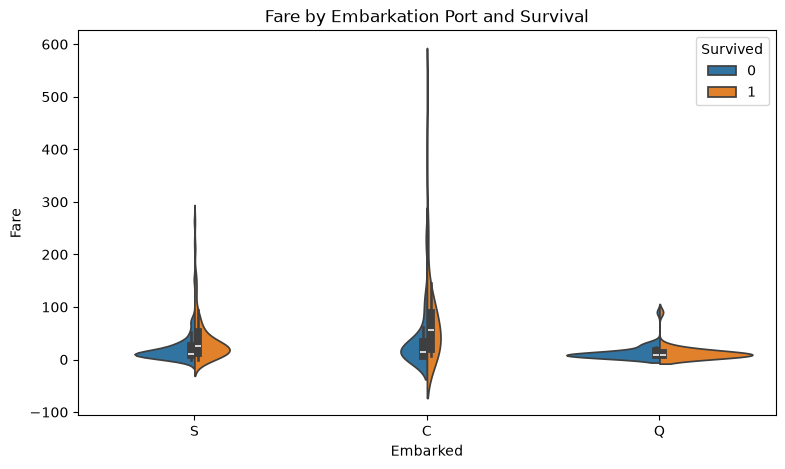

In [45]:
plt.figure(figsize=(9, 5))

sns.violinplot(
    data=eda,
    x="Embarked",
    y="Fare",
    hue="Survived",
    split=True
)

plt.title("Fare by Embarkation Port and Survival")
plt.show()

# Part II — Feature Engineering

Now we turn raw Titanic columns into features that a model can use.

Our structure will be:

```text
train → X + y
test  → X_test

X + X_test → all_data
```

We temporarily combine the feature rows so the same transformations are applied to both datasets.

In [46]:
# Target
y = train["Survived"].copy()

# Kaggle needs these IDs in the final submission
test_ids = test["PassengerId"].copy()

# Training features
X = train.drop(columns=["Survived"])

# Combine train features + test features
all_data = pd.concat(
    [X, test],
    ignore_index=True
)

# PassengerId is not used as a model feature in this solution
all_data = all_data.drop(columns=["PassengerId"])

train_rows = len(train)

print("Combined shape:", all_data.shape)
all_data.head()

Combined shape: (1309, 10)


,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Two important syntax patterns

```python
pd.concat([A, B], ignore_index=True)
```

means **put dataframe B underneath dataframe A**.

```python
len(train)
```

gives the number of training rows. We save that so we can split `all_data` back later.

## 10. Extract Title from Name

Examples:

```text
Braund, Mr. Owen Harris       → Mr
Heikkinen, Miss. Laina        → Miss
Peter, Master. Michael J      → Master
```

Instead of hiding the logic inside one complicated line, we break it into small steps.

In [47]:
def get_title(name):
    after_comma = name.split(",")[1]
    before_dot = after_comma.split(".")[0]
    title = before_dot.strip()

    return title


all_data["Title"] = all_data["Name"].apply(get_title)

all_data["Title"].value_counts()

Title
Mr              757
Miss            260
Mrs             197
Master           61
Rev               8
Dr                8
Col               4
Ms                2
Major             2
Mlle              2
Don               1
Mme               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Dona              1
Name: count, dtype: int64

### Function structure to remember

```python
def function_name(input):
    # do something
    return result
```

And:

```python
series.apply(function_name)
```

runs that function on every value in the Series.

## 11. Merge uncommon titles into larger groups

This is the same main idea used in the original notebook.

We also include `Dona`, which appeared in the test data and was missing from the old mapping.

In [48]:
title_map = {
    "Capt": "Officer",
    "Col": "Officer",
    "Major": "Officer",
    "Dr": "Officer",
    "Rev": "Officer",

    "Jonkheer": "Royalty",
    "Don": "Royalty",
    "Sir": "Royalty",
    "Lady": "Royalty",
    "the Countess": "Royalty",
    "Dona": "Royalty",

    "Mme": "Mrs",
    "Mlle": "Miss",
    "Ms": "Mrs",

    "Mr": "Mr",
    "Mrs": "Mrs",
    "Miss": "Miss",
    "Master": "Master"
}

all_data["Title"] = all_data["Title"].map(title_map)

all_data["Title"].value_counts(dropna=False)

Title
Mr         757
Miss       262
Mrs        200
Master      61
Officer     23
Royalty      6
Name: count, dtype: int64

### Mapping pattern to remember

```python
df["column"] = df["column"].map({
    "old_value": "new_value"
})
```

It replaces values according to a dictionary.

## 12. Fill missing Age intelligently

Instead of filling every missing age with one global number, the original solution estimates age from:

- `Sex`
- `Pclass`
- `Title`

We calculate the median ages using **training rows only**.

In [49]:
train_part = all_data.iloc[:train_rows]

age_medians = (
    train_part
    .groupby(["Sex", "Pclass", "Title"])["Age"]
    .median()
)

overall_age_median = train_part["Age"].median()

age_medians.head()

Sex     Pclass  Title  
female  1       Miss       30.0
                Mrs        40.0
                Officer    49.0
                Royalty    40.5
        2       Miss       24.0
Name: Age, dtype: float64

In [50]:
def fill_age(row):
    # If Age already exists, keep it
    if pd.notna(row["Age"]):
        return row["Age"]

    # Otherwise look for the median of the same Sex + Pclass + Title group
    group = (
        row["Sex"],
        row["Pclass"],
        row["Title"]
    )

    return age_medians.get(group, overall_age_median)


all_data["Age"] = all_data.apply(
    fill_age,
    axis=1
)

print("Missing Age values:", all_data["Age"].isna().sum())

Missing Age values: 0


### Why `axis=1`?

```python
df.apply(function, axis=1)
```

means:

> run the function **row by row**

Inside `fill_age(row)`, `row["Sex"]`, `row["Pclass"]`, etc. refer to values from one passenger.

## 13. Fill missing Fare

In [51]:
train_fare_mean = all_data.iloc[:train_rows]["Fare"].mean()

all_data["Fare"] = all_data["Fare"].fillna(train_fare_mean)

print("Missing Fare values:", all_data["Fare"].isna().sum())

Missing Fare values: 0


## 14. Fill missing Embarked

In [52]:
most_common_port = (
    all_data
    .iloc[:train_rows]["Embarked"]
    .mode()[0]
)

all_data["Embarked"] = all_data["Embarked"].fillna(most_common_port)

print("Most common port:", most_common_port)
print("Missing Embarked values:", all_data["Embarked"].isna().sum())

Most common port: S
Missing Embarked values: 0


`mode()` means **most frequent value**.

```python
series.mode()[0]
```

takes the first most-common value.

## 15. Simplify Cabin

A cabin like:

```text
C85
E46
B28
```

becomes:

```text
C
E
B
```

Missing cabin becomes `U` = Unknown.

In [53]:
all_data["Cabin"] = all_data["Cabin"].fillna("U")

all_data["Cabin"] = all_data["Cabin"].str[0]

all_data["Cabin"].value_counts()

Cabin
U    1014
C      94
B      65
D      46
E      41
A      22
F      21
G       5
T       1
Name: count, dtype: int64

### String indexing pattern

```python
series.str[0]
```

means:

> take the first character from every string

## 16. Convert Sex to numbers

In [54]:
all_data["Sex"] = all_data["Sex"].map({
    "female": 0,
    "male": 1
})

all_data["Sex"].value_counts()

Sex
1    843
0    466
Name: count, dtype: int64

## 17. Extract Ticket Prefix

Examples:

```text
A/5 21171       → A5
PC 17599        → PC
STON/O2. 3101282 → STONO2
113803          → XXX
```

If the ticket contains no text prefix, we use `XXX`.

In [55]:
def get_ticket_prefix(ticket):
    ticket = ticket.replace(".", "")
    ticket = ticket.replace("/", "")

    parts = ticket.split()

    for part in parts:
        if not part.isdigit():
            return part

    return "XXX"


all_data["TicketPrefix"] = all_data["Ticket"].apply(get_ticket_prefix)

all_data["TicketPrefix"].value_counts().head(10)

TicketPrefix
XXX        957
PC          92
CA          68
A5          28
SOTONOQ     24
WC          15
STONO       14
SCPARIS     14
A4          10
FCC          9
Name: count, dtype: int64

## 18. Create Family features

Original idea:

```text
FamilySize  = siblings/spouses + parents/children + the passenger
Singleton   = alone
SmallFamily = family size 2 to 4
LargeFamily = family size 5+
```

In [56]:
all_data["FamilySize"] = (
    all_data["SibSp"]
    + all_data["Parch"]
    + 1
)

all_data["Singleton"] = (
    all_data["FamilySize"] == 1
).astype(int)

all_data["SmallFamily"] = (
    all_data["FamilySize"].between(2, 4)
).astype(int)

all_data["LargeFamily"] = (
    all_data["FamilySize"] >= 5
).astype(int)

all_data[[
    "SibSp",
    "Parch",
    "FamilySize",
    "Singleton",
    "SmallFamily",
    "LargeFamily"
]].head()

,SibSp,Parch,FamilySize,Singleton,SmallFamily,LargeFamily
0,1,0,2,0,1,0
1,1,0,2,0,1,0
2,0,0,1,1,0,0
3,1,0,2,0,1,0
4,0,0,1,1,0,0


### Boolean → 0/1 pattern

```python
(condition).astype(int)
```

Example:

```python
(df["Age"] >= 18).astype(int)
```

produces:

```text
True  → 1
False → 0
```

## 19. Remove raw text columns we no longer need

We already extracted useful information from:

- `Name` → `Title`
- `Ticket` → `TicketPrefix`

In [57]:
all_data = all_data.drop(
    columns=["Name", "Ticket"]
)

## 20. One-hot encode categorical columns

Machine-learning models cannot directly understand values like:

```text
Mr
Mrs
C
S
Royalty
```

So `pd.get_dummies()` turns categories into 0/1 columns.

In [58]:
categorical_columns = [
    "Title",
    "Embarked",
    "Cabin",
    "Pclass",
    "TicketPrefix"
]

all_data = pd.get_dummies(
    all_data,
    columns=categorical_columns,
    dtype=int
)

print("Final feature count:", all_data.shape[1])
all_data.head()

Final feature count: 67


,Sex,Age,SibSp,Parch,Fare,FamilySize,Singleton,SmallFamily,LargeFamily,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Officer,Title_Royalty,Embarked_C,Embarked_Q,Embarked_S,Cabin_A,Cabin_B,Cabin_C,Cabin_D,Cabin_E,Cabin_F,Cabin_G,Cabin_T,Cabin_U,Pclass_1,Pclass_2,Pclass_3,TicketPrefix_A,TicketPrefix_A4,TicketPrefix_A5,TicketPrefix_AQ3,TicketPrefix_AQ4,TicketPrefix_AS,TicketPrefix_C,TicketPrefix_CA,TicketPrefix_CASOTON,TicketPrefix_FC,TicketPrefix_FCC,TicketPrefix_Fa,TicketPrefix_LINE,TicketPrefix_LP,TicketPrefix_PC,TicketPrefix_PP,TicketPrefix_PPP,TicketPrefix_SC,TicketPrefix_SCA3,TicketPrefix_SCA4,TicketPrefix_SCAH,TicketPrefix_SCOW,TicketPrefix_SCPARIS,TicketPrefix_SCParis,TicketPrefix_SOC,TicketPrefix_SOP,TicketPrefix_SOPP,TicketPrefix_SOTONO2,TicketPrefix_SOTONOQ,TicketPrefix_SP,TicketPrefix_STONO,TicketPrefix_STONO2,TicketPrefix_STONOQ,TicketPrefix_SWPP,TicketPrefix_WC,TicketPrefix_WEP,TicketPrefix_XXX
0,1,22.0,1,0,7.2500,2,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,38.0,1,0,71.2833,2,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,26.0,0,0,7.9250,1,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,0,35.0,1,0,53.1000,2,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,1,35.0,0,0,8.0500,1,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


Example of dummy encoding:

```text
Title
Mr
Miss
Mrs
```

becomes something like:

```text
Title_Mr   Title_Miss   Title_Mrs
1          0            0
0          1            0
0          0            1
```

## 21. Final missing-value check

In [59]:
missing = all_data.isna().sum()

missing[missing > 0]

Series([], dtype: int64)

If the output above is empty, feature engineering is complete.

## 22. Split `all_data` back into `X` and `X_test`

Remember:

```text
first 891 rows → original training passengers
remaining rows → Kaggle test passengers
```

In [60]:
X = all_data.iloc[:train_rows].copy()
X_test = all_data.iloc[train_rows:].copy()

print("X shape     :", X.shape)
print("y shape     :", y.shape)
print("X_test shape:", X_test.shape)

X shape     : (891, 67)
y shape     : (891,)
X_test shape: (418, 67)


### `.iloc` pattern to remember

```python
df.iloc[:n]
```

means **rows from the beginning up to `n`**.

```python
df.iloc[n:]
```

means **rows from `n` until the end**.

# Part III — Modeling

## 23. Simple cross-validation helper

Instead of one train/validation split, the original solution evaluates models using **5-fold cross-validation**.

In [61]:
def cv_score(model, X_data, y_data):
    scores = cross_val_score(
        model,
        X_data,
        y_data,
        cv=5,
        scoring="accuracy"
    )

    return scores.mean()

## 24. Feature importance

A Random Forest can estimate which features matter most.

In [62]:
importance_model = RandomForestClassifier(
    n_estimators=50,
    max_features="sqrt",
    random_state=42
)

importance_model.fit(X, y)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
1,Age,0.195591
4,Fare,0.169936
0,Sex,0.112518
11,Title_Mr,0.112442
29,Pclass_3,0.037205
10,Title_Miss,0.036979
5,FamilySize,0.033741
12,Title_Mrs,0.029613
2,SibSp,0.024935
26,Cabin_U,0.024712


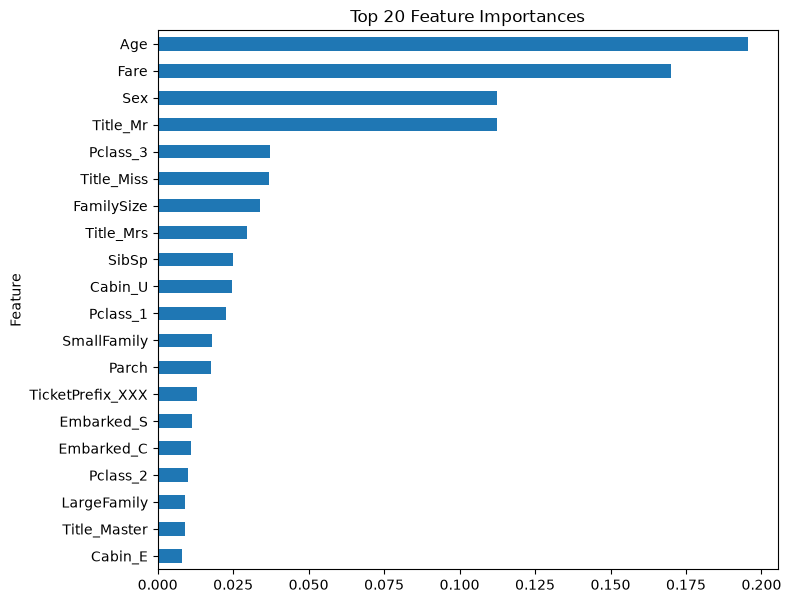

In [63]:
top_features = feature_importance.head(20).sort_values("Importance")

top_features.plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(8, 7),
    legend=False
)

plt.title("Top 20 Feature Importances")
plt.show()

## 25. Optional feature-selection experiment

The original notebook tested a smaller feature set using `SelectFromModel`.

The **final Random Forest still uses the full feature set**, just like the original solution.

In [64]:
selector = SelectFromModel(
    importance_model,
    prefit=True
)

X_reduced = selector.transform(X)
X_test_reduced = selector.transform(X_test)

print("Full X shape   :", X.shape)
print("Reduced X shape:", X_reduced.shape)

Full X shape   : (891, 67)
Reduced X shape: (891, 13)


## 26. Compare a few base models

In [65]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Logistic Regression CV": LogisticRegressionCV(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    score = cv_score(model, X_reduced, y)
    print(name, ":", round(score, 4))

Logistic Regression : 0.8204
Logistic Regression CV : 0.8215
Random Forest : 0.8092
Gradient Boosting : 0.8305


# Part IV — Random Forest Tuning

The original notebook used Random Forest as the final model.

It also performed a grid search and reported this parameter combination:

```text
bootstrap=False
min_samples_leaf=3
n_estimators=50
min_samples_split=10
max_features="sqrt"
max_depth=6
```

We keep those values as the default so you do not have to run GridSearch every time.

## 27. Optional Grid Search

Set:

```python
RUN_GRID_SEARCH = True
```

only when you actually want to search many parameter combinations.

`"auto"` from the old notebook is not included because modern scikit-learn no longer uses it for this classifier.

In [66]:
RUN_GRID_SEARCH = False

if RUN_GRID_SEARCH:
    parameter_grid = {
        "max_depth": [4, 6, 8],
        "n_estimators": [10, 50],
        "max_features": ["sqrt", "log2"],
        "min_samples_split": [2, 3, 10],
        "min_samples_leaf": [1, 3, 10],
        "bootstrap": [True, False]
    }

    forest = RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    )

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    grid_search = GridSearchCV(
        estimator=forest,
        param_grid=parameter_grid,
        scoring="accuracy",
        cv=cv,
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X, y)

    model = grid_search.best_estimator_

    print("Best score:", grid_search.best_score_)
    print("Best parameters:", grid_search.best_params_)

else:
    model = RandomForestClassifier(
        bootstrap=False,
        min_samples_leaf=3,
        n_estimators=50,
        min_samples_split=10,
        max_features="sqrt",
        max_depth=6,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X, y)

## 28. Check the final model with cross-validation

In [67]:
final_cv = cv_score(model, X, y)

print("5-fold CV accuracy:", round(final_cv, 4))

5-fold CV accuracy: 0.8316


# Part V — Kaggle Submission

In [68]:
predictions = model.predict(X_test).astype(int)

submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Survived": predictions
})

submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [72]:
SUBMISSION_PATH = Path(r"C:\Users\whelm\OneDrive\Desktop\submission_81_percent.csv")
submission.to_csv(
    SUBMISSION_PATH,
    index=False
)

print(f"Saved: {SUBMISSION_PATH}")

Saved: C:\Users\whelm\OneDrive\Desktop\submission_81_percent.csv


The submission structure must be exactly:

```text
PassengerId | Survived
```

Kaggle compares your `Survived` predictions with its hidden answers.

# Part VI — Bonus: Simple Model Blending

The original notebook also showed a bonus idea:

1. train several different models
2. get each model's survival probability
3. average the probabilities
4. convert the average into `0` or `1`

This is optional.

In [70]:
blend_models = [
    LogisticRegression(max_iter=1000),
    LogisticRegressionCV(max_iter=1000),
    RandomForestClassifier(random_state=42),
    GradientBoostingClassifier(random_state=42)
]

probabilities = []

for blend_model in blend_models:
    blend_model.fit(X, y)

    prob = blend_model.predict_proba(X_test)[:, 1]
    probabilities.append(prob)

average_probability = np.mean(
    probabilities,
    axis=0
)

blend_predictions = (
    average_probability >= 0.5
).astype(int)

blend_submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Survived": blend_predictions
})

blend_submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [71]:
blend_submission.to_csv(
    "submission_blended.csv",
    index=False
)

print("Saved: submission_blended.csv")

Saved: submission_blended.csv


# Final mental map

Do not memorize the notebook line by line. Remember the pipeline:

```text
1. Load train + test

2. EDA
   ↓
   understand Sex, Age, Fare, Pclass, Embarked

3. Separate
   X = features
   y = Survived

4. Combine X + test temporarily
   ↓
   same feature engineering

5. Create useful features
   Name   → Title
   Age    → group-based missing-value filling
   Cabin  → first letter
   Ticket → ticket prefix
   family → FamilySize / Singleton / SmallFamily / LargeFamily

6. Convert categories to numbers
   ↓
   get_dummies()

7. Split back
   all_data → X + X_test

8. Train Random Forest
   ↓

9. Predict X_test
   ↓

10. Create submission.csv
```

That pipeline is much more important than memorizing any single syntax.